# # Linear Regression on the Diabetes Dataset
#
# In this example, we demonstrate how to:
# - Load the Diabetes dataset from `sklearn`
# - Explore and understand the data using pandas
# - Split the data into training and test sets
# - Train a custom `LinearRegression` model from `rice_ml`
# - Evaluate the model using R² and RMSE on both train and test sets
# - Visualize the predictions vs. true target values
#
# This notebook is meant to be a **full workflow example**:
# data exploration → preprocessing → modeling → evaluation → visualization.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Make sure we can import from the src/ directory
ROOT_DIR = Path.cwd().parents[2]      # project root (…/CMOR438)
SRC_PATH = ROOT_DIR / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from rice_ml.supervised_learning.linear_regression import LinearRegression
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# ## 1. Load the Diabetes dataset
#
# The Diabetes dataset is a classic regression dataset in `sklearn`.  
# It contains:
# - 442 samples (patients)
# - 10 numeric features measured at baseline (e.g., age, BMI, blood pressure)
# - A continuous target: a quantitative measure of disease progression
#
# We first load the dataset and inspect its basic structure.

In [3]:
# Load the diabetes dataset
diabetes = load_diabetes()

X = diabetes.data        # feature matrix (numpy array)
y = diabetes.target      # target values (disease progression)
feature_names = diabetes.feature_names

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Feature names:", feature_names)

Number of samples: 442
Number of features: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


# ## 2. Create a pandas DataFrame and inspect the data
#
# For easier exploration, we convert the numpy arrays into a pandas
# `DataFrame`. This allows us to:
# - Quickly view the first few rows
# - Compute summary statistics
# - Inspect correlations between features and the target variable.

In [4]:
# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

# Show the first five rows
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# ### 2.1 Summary statistics
#
# `DataFrame.describe()` gives us basic statistics (mean, std, min, max, quartiles)
# for each feature and the target. This helps us understand the scale
# and distribution of the variables.

In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


# ### 2.2 Correlation with the target
#
# We can also examine how each feature correlates with the target variable.
# A higher absolute correlation (positive or negative) suggests that the
# feature may be more predictive for the regression model.

In [6]:
corr_with_target = df.corr(numeric_only=True)["target"].sort_values(ascending=False)
corr_with_target

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

# ## 3. Train–test split (Preprocessing step)
#
# To evaluate how well our model generalizes, we split the data into:
# - **Training set**: used to fit the model
# - **Test set**: used only for evaluation
#
# Here we use an 80/20 split and fix `random_state=42` for reproducibility.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (353, 10) (353,)
Test shape: (89, 10) (89,)


# > **Note:** In a more advanced workflow, we might also standardize the features
# > (e.g., subtract mean and divide by standard deviation). For this example,
# > we keep the raw features to focus on the linear regression implementation.

# ## 4. Fit the custom Linear Regression model
#
# We now use the `LinearRegression` implementation from our `rice_ml` package.
# The model API supports:
# - `fit(X, y)`: fit the model
# - `predict(X)`: make predictions
# - `coef_` and `intercept_`: learned parameters
# - `R2()` and `RMSE()`: training metrics
#
# We first fit the model on the **training set**.

In [8]:
lin_reg = LinearRegression(fit_intercept=True)

lin_reg.fit(X_train, y_train)

print("Coefficients (beta):", lin_reg.coef_)
print("Intercept (beta_0):", lin_reg.intercept_)
print("Train R^2:", lin_reg.R2())
print("Train RMSE:", lin_reg.RMSE())

Coefficients (beta): [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Intercept (beta_0): 151.34560453985998
Train R^2: 0.5279193863361498
Train RMSE: 54.41335311641091


# ## 5. Evaluate on the test set
#
# To measure generalization performance, we:
# 1. Use `predict` on `X_test` to obtain predictions.
# 2. Compute:
#    - **R²** (coefficient of determination): how much variance in the target
#      is explained by the model.
#    - **RMSE** (root mean squared error): the average magnitude of prediction error.

In [9]:
# Predict on the test set
y_pred_test = lin_reg.predict(X_test)

# Calculate R^2 on the test set
ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2_test = 1 - ss_res / ss_tot

# Calculate RMSE on the test set
rmse_test = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

print(f"Test R^2:  {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")

Test R^2:  0.4526
Test RMSE: 53.8534


# ## 6. Visualization: True vs. Predicted values
#
# A simple way to visually inspect model performance is to plot:
# - x-axis: true target values (`y_test`)
# - y-axis: predicted target values (`y_pred_test`)
#
# If the model were perfect, all points would lie exactly on the diagonal line
# `y = x`. The more tightly the points cluster around this line, the better the fit.

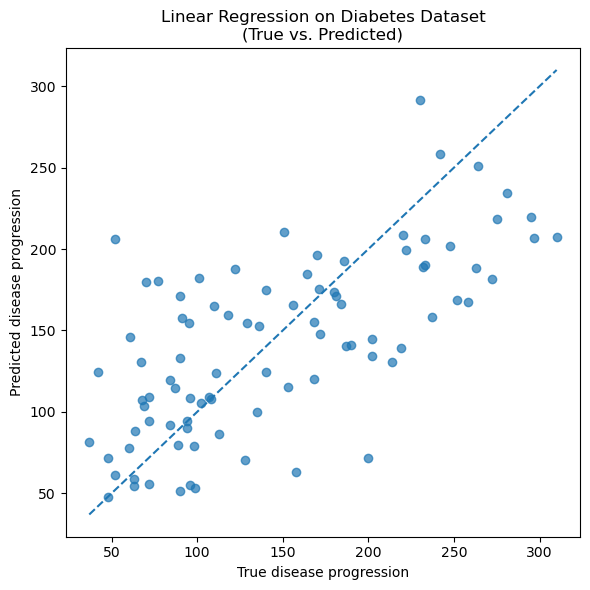

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
)
plt.xlabel("True disease progression")
plt.ylabel("Predicted disease progression")
plt.title("Linear Regression on Diabetes Dataset\n(True vs. Predicted)")
plt.tight_layout()
plt.show()

# ## 7. Summary
#
# In this example notebook, we:
#
# - Loaded the Diabetes dataset and converted it into a pandas `DataFrame`
# - Performed basic exploratory data analysis (summary statistics, correlations)
# - Split the data into training and test sets
# - Trained a custom `LinearRegression` model from the `rice_ml` package
# - Evaluated the model using R² and RMSE on both training and test sets
# - Visualized predicted vs. true target values
#
# This demonstrates a complete **end-to-end regression workflow**:
# from raw data → exploration → preprocessing → modeling → evaluation → visualization.